# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [28]:
# Importing Libraries
import numpy as np
import pandas as pd

In [29]:
# Importing the datasets
salary_data = pd.read_csv('2025_salaries.csv', header=1)
stats_data = pd.read_csv('nba_2025.txt', sep=",", encoding='latin-1')

salary_data.head()
stats_data.head()   

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,1.0,Shai Gilgeous-Alexander,27.0,OKC,PG,49.0,49.0,1632.0,534.0,964.0,...,218.0,314.0,64.0,38.0,103.0,101.0,1558.0,0.0,NaN,gilgesh01
1,2.0,Tyrese Maxey,25.0,PHI,PG,52.0,52.0,2008.0,524.0,1117.0,...,214.0,351.0,102.0,40.0,126.0,118.0,1503.0,0.0,NaN,maxeyty01
2,3.0,Donovan Mitchell,29.0,CLE,SG,51.0,51.0,1719.0,516.0,1060.0,...,229.0,302.0,79.0,15.0,159.0,125.0,1478.0,0.0,NaN,mitchdo01
3,4.0,Jaylen Brown,29.0,BOS,SF,49.0,49.0,1676.0,534.0,1105.0,...,336.0,229.0,49.0,20.0,176.0,136.0,1435.0,2.0,NaN,brownja02
4,5.0,Luka DonÄiÄ,26.0,LAL,PG,42.0,42.0,1492.0,437.0,923.0,...,329.0,360.0,61.0,19.0,179.0,102.0,1379.0,6.0,NaN,doncilu01


In [30]:
# I will be cleaning the datasets seperatley to ensure a clean merged dataset.
#Drop variables that will not be needed or are duplicates
#Changing column name to Salary
salary_data = salary_data.rename(columns={'2025-26': 'Salary'})
salary_data = salary_data.drop_duplicates()
salary_data = salary_data.dropna(subset=['Salary'])
#Remove leading and trailing spaces from the 'Player' column for simplicity
salary_data['Player'] = salary_data['Player'].str.strip() 
salary_data.head()

,Player,Tm,Salary
0,Jaden Springer,NOP,"$70,732"
1,Garrison Mathews,IND,"$131,970"
3,Mac McClung,IND,"$164,060"
4,Didi Louzada,POR,"$268,032"
5,Monte Morris,IND,"$321,184"


In [31]:
# Cleaning the stats dataset
stats_data = stats_data.drop_duplicates()
stats_data = stats_data.dropna(subset=['Player'])

#Remove leading and trailing spaces from the 'Player' column for simplicity
stats_data['Player'] = stats_data['Player'].str.strip()

# To prevent further plotting issues with the name character errors, I research how to remove these unique characters
stats_data['player'] = stats_data['Player'].str.encode("ascii", "ignore").str.decode("ascii")
stats_data.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,player
0,1.0,Shai Gilgeous-Alexander,27.0,OKC,PG,49.0,49.0,1632.0,534.0,964.0,...,314.0,64.0,38.0,103.0,101.0,1558.0,0.0,NaN,gilgesh01,Shai Gilgeous-Alexander
1,2.0,Tyrese Maxey,25.0,PHI,PG,52.0,52.0,2008.0,524.0,1117.0,...,351.0,102.0,40.0,126.0,118.0,1503.0,0.0,NaN,maxeyty01,Tyrese Maxey
2,3.0,Donovan Mitchell,29.0,CLE,SG,51.0,51.0,1719.0,516.0,1060.0,...,302.0,79.0,15.0,159.0,125.0,1478.0,0.0,NaN,mitchdo01,Donovan Mitchell
3,4.0,Jaylen Brown,29.0,BOS,SF,49.0,49.0,1676.0,534.0,1105.0,...,229.0,49.0,20.0,176.0,136.0,1435.0,2.0,NaN,brownja02,Jaylen Brown
4,5.0,Luka DonÄiÄ,26.0,LAL,PG,42.0,42.0,1492.0,437.0,923.0,...,360.0,61.0,19.0,179.0,102.0,1379.0,6.0,NaN,doncilu01,Luka Doni


In [32]:
# Merging both datasets and performing minor checks and cleans if needed
nba_data = pd.merge(stats_data, salary_data, on='Player')
nba_data.info()
nba_data.isnull().sum()
nba_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 523 non-null    float64
 1   Player             523 non-null    str    
 2   Age                523 non-null    float64
 3   Team               523 non-null    str    
 4   Pos                523 non-null    str    
 5   G                  523 non-null    float64
 6   GS                 523 non-null    float64
 7   MP                 523 non-null    float64
 8   FG                 523 non-null    float64
 9   FGA                523 non-null    float64
 10  FG%                522 non-null    float64
 11  3P                 523 non-null    float64
 12  3PA                523 non-null    float64
 13  3P%                496 non-null    float64
 14  2P                 523 non-null    float64
 15  2PA                523 non-null    float64
 16  2P%                520 non-null    fl

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional,player,Tm,Salary
0,1.0,Shai Gilgeous-Alexander,27.0,OKC,PG,49.0,49.0,1632.0,534.0,964.0,...,38.0,103.0,101.0,1558.0,0.0,NaN,gilgesh01,Shai Gilgeous-Alexander,OKC,"$38,333,050"
1,2.0,Tyrese Maxey,25.0,PHI,PG,52.0,52.0,2008.0,524.0,1117.0,...,40.0,126.0,118.0,1503.0,0.0,NaN,maxeyty01,Tyrese Maxey,PHI,"$37,958,760"
2,3.0,Donovan Mitchell,29.0,CLE,SG,51.0,51.0,1719.0,516.0,1060.0,...,15.0,159.0,125.0,1478.0,0.0,NaN,mitchdo01,Donovan Mitchell,CLE,"$46,394,100"
3,4.0,Jaylen Brown,29.0,BOS,SF,49.0,49.0,1676.0,534.0,1105.0,...,20.0,176.0,136.0,1435.0,2.0,NaN,brownja02,Jaylen Brown,BOS,"$53,142,264"
4,6.0,Jalen Brunson,29.0,NYK,PG,50.0,50.0,1728.0,481.0,1024.0,...,5.0,110.0,116.0,1351.0,0.0,NaN,brunsja01,Jalen Brunson,NYK,"$34,944,001"


In [33]:
#Run the clustering algo with your best guess for K
#First, I'm going to be choosing stats that coorelate with a players skill
#But first...Imports for SK
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#I decided to narrow it down to these. Turnovers will be helpful determining if a players skill is sloppy or not
#I will narrow it down if needed to later
features = nba_data[[ 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'GS', 'MP']]

# Scaling features to make them equally as important, because the range of values for each stat is different
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

#Running KMeans with an initial guess of 4 clusters to start
#Random State ensures that the results are reproducible (self note)
#Fitting our model to the data
kmeans = KMeans(n_clusters=4, random_state=42)
nba_data['Cluster'] = kmeans.fit_predict(scaled_features)

# Evaluate the clustering results
#(Note) The silhouette score ranges from -1 to 1, where a higher score indicates better defined clusters
# A score close to 0 means that clusters may be overlapping
score = silhouette_score(scaled_features, nba_data['Cluster'])
print("Score:", score)

Score: 0.4162677662415049


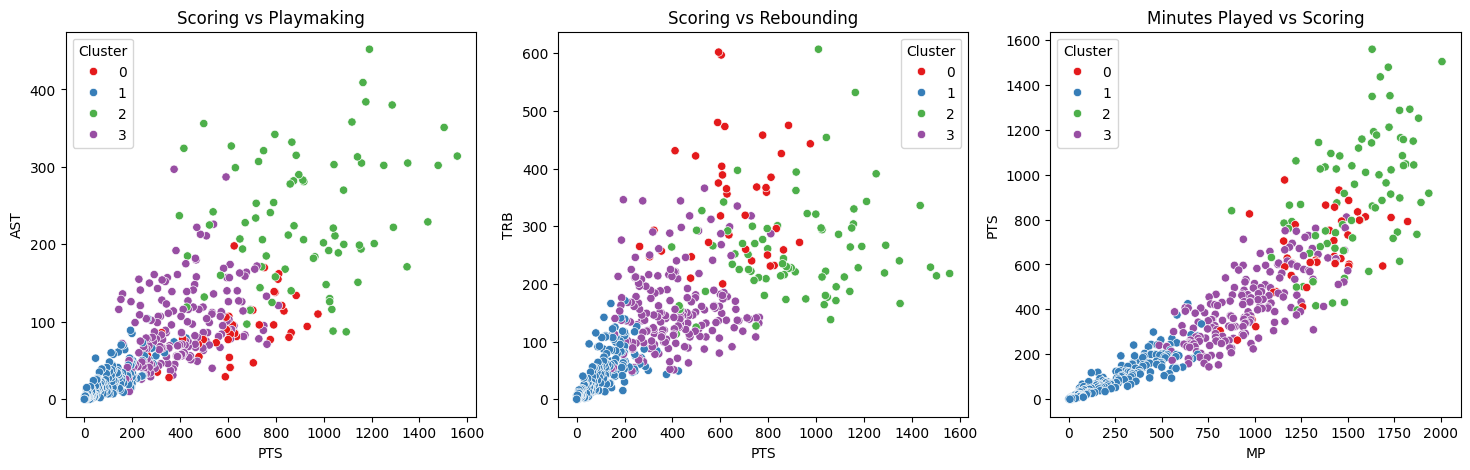

In [34]:
#View the results
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Plot 1
# #Comparing these two features separates the ballers that score often vs the ones that move the ball and create points
sns.scatterplot(
    data=nba_data,
    x="PTS",
    y="AST",
    hue="Cluster",
    palette="Set1",
    ax=axes[0]
)
axes[0].set_title("Scoring vs Playmaking")



# Plot 2
# Plotting these features separates the big players from the smaller guards, aka paint vs shooters
sns.scatterplot(
    data=nba_data,
    x="PTS",
    y="TRB",
    hue="Cluster",
    palette="Set1",
    ax=axes[1]
)
axes[1].set_title("Scoring vs Rebounding")


# Plot 3
# Comparing these two features shows the role of the player in the game vs their actual productive contribution
sns.scatterplot(
    data=nba_data,
    x="MP",
    y="PTS",
    hue="Cluster",
    palette="Set1",
    ax=axes[2]
)
axes[2].set_title("Minutes Played vs Scoring")

plt.tight_layout
plt.show()

#### Seeing this score makes me curious about players stats and their corresponding seasons. I'm aware that most of these are good determinants of whether or not a player is good, and yes, they do overlap a bit, but thats reasonable given basketball stats mostly correlate. However, I can't help but wonder, if the whole point of Mr. Rooney's action is to scout the best valued players for a better team, this approach is letting injured, underused, and scrappy-breakout players go unnoticed. By recording each stat as a seasonal stat, we are increasing the risk of limiting ourselves to players that show durability, which is great, but undermines skill. When altering stats to be on a per-game basis, we can make more detailed and justified observations on how productive a player actually is on the court --->>> The only tradeoff being players that play less minutes has to be normalized with a per-36 minute stat, showing what the players would like if they played the full game...

##### I would like to explore if this option produces better results, find out below 

In [35]:
nba_data2 = pd.read_csv('nba_data.csv')

In [36]:
# Precautionary measure: dropping players that have 0 games or 0 minutes played
nba_data2 = nba_data2[nba_data2["G"] >= 15]

# Dividing each stat by game to get the per-game stats
nba_data2["PTS_pg"] = nba_data2["PTS"] / nba_data2["G"] 
nba_data2["TRB_pg"] = nba_data2["TRB"] / nba_data2["G"]
nba_data2["AST_pg"] = nba_data2["AST"] / nba_data2["G"]
nba_data2["STL_pg"] = nba_data2["STL"] / nba_data2["G"]
nba_data2["BLK_pg"] = nba_data2["BLK"] / nba_data2["G"]
nba_data2["TOV_pg"] = nba_data2["TOV"] / nba_data2["G"]
nba_data2["MP_pg"] = nba_data2["MP"] / nba_data2["G"]

# Keeping rotation players
nba_data2 = nba_data2[nba_data2["MP"] >= 12]

# Print the remaining players to see who is left after filtering
print("Players:", len(nba_data2))



Players: 435


In [37]:
# Re-run libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Now that we have further advanced stats, lets re-cluster and figure out if we get better results
features = nba_data2[[ 'PTS_pg', 'TRB_pg', 'AST_pg', 'STL_pg', 'BLK_pg', 'TOV_pg', 'MP_pg']]

# Re-run our scaler and kmeans functions
scaler = StandardScaler()
scaled_features_pg = scaler.fit_transform(features)
kmeans = KMeans(n_clusters=4, random_state=42)
nba_data2["Cluster_pg"] = kmeans.fit_predict(scaled_features_pg)

#Time for scoring
#View the results
score_pg = silhouette_score(scaled_features_pg, nba_data2["Cluster_pg"])
print("score_pg", score_pg)


score_pg 0.3085525090763887


##### While this silhouette score was lower, I believe the filters and per-game breakdown will help us pick more valuable player.

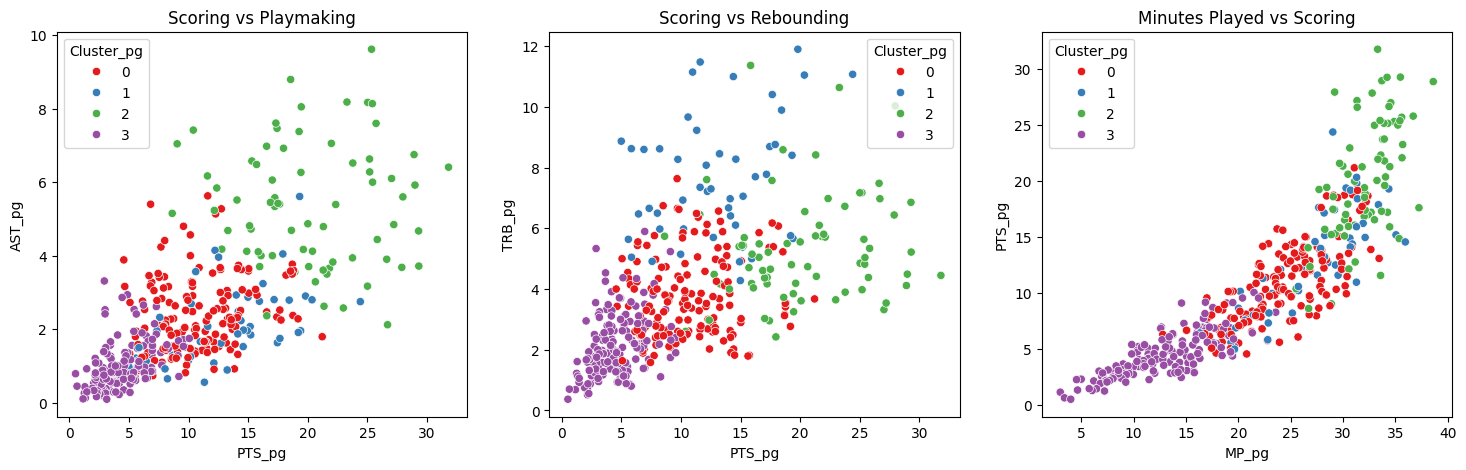

In [38]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

#Plotting them side by side for easier visuals
import matplotlib.pyplot as plt 
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Plot 1
# #Comparing these two features separates the ballers that score often vs the ones that move the ball and create points
sns.scatterplot(
    data=nba_data2,
    x="PTS_pg",
    y="AST_pg",
    hue="Cluster_pg",
    palette="Set1",
    ax=axes[0]
)
axes[0].set_title("Scoring vs Playmaking")



# Plot 2
# Plotting these features separates the big players from the smaller guards, aka paint vs shooters
sns.scatterplot(
    data=nba_data2,
    x="PTS_pg",
    y="TRB_pg",
    hue="Cluster_pg",
    palette="Set1",
    ax=axes[1]
)
axes[1].set_title("Scoring vs Rebounding")


# Plot 3
# Comparing these two features shows the role of the player in the game vs their actual productive contribution
sns.scatterplot(
    data=nba_data2,
    x="MP_pg",
    y="PTS_pg",
    hue="Cluster_pg",
    palette="Set1",
    ax=axes[2]
)
axes[2].set_title("Minutes Played vs Scoring")

plt.tight_layout
plt.show()

In [39]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores

# Score per game from before
score_pg = silhouette_score(scaled_features_pg, nba_data2["Cluster_pg"])
print("score_pg", score_pg)

# Total Sum of Squares
overall_mean = np.mean(scaled_features, axis=0)
tss = np.sum((scaled_features - overall_mean)**2)

# Within-cluster sum of squares
wcss = kmeans.inertia_

# Variance explained 
v_explained = 1 - (wcss / tss)

print("V explained:", v_explained)

score_pg 0.3085525090763887
V explained: 0.7384372814143293


##### My silhouette score measures how cleanly separated my cluster are. Since basketball is a very universally skill-dependent sport, most features rely on the others, with points being king. Variance explained tells me how much total variation my clusters capture. In this model, they explain 74% variation in performance

In [40]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient

# Creating a for-loop for testing K values to identify how many clusters we should use
for k in [2, 3, 4, 5]:
    model = KMeans(n_clusters=k, random_state=42)
    label = model.fit_predict(scaled_features)
    inertia = model.inertia_
    silhouette = silhouette_score(scaled_features, label)

    # Printing values
    print("k:", k)
    print("inertia:", inertia)
    print("silhouette:", silhouette)

k: 2
inertia: 1956.1908977379799
silhouette: 0.4657103840887553
k: 3
inertia: 1385.8538243863043
silhouette: 0.40833199987276875
k: 4
inertia: 1145.8162427006314
silhouette: 0.4162677662415049
k: 5
inertia: 990.1360235071193
silhouette: 0.36031765214279693


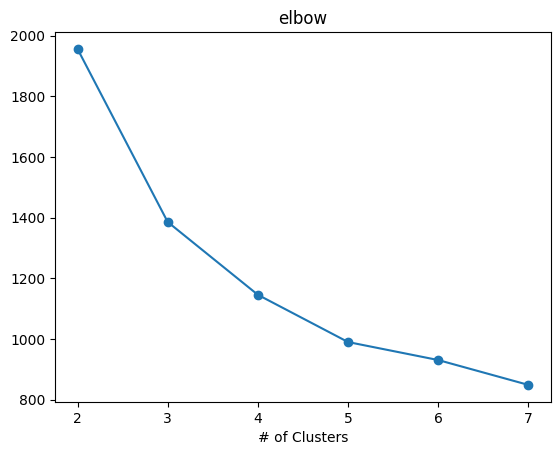

In [41]:
#Visualize the results of the elbow method

#Creating another simple for-loop based on the previous one top flow into my visualization
inertia = []
k_values = range(2,8)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertia.append(model.inertia_) # append saves the inertia value for that specific k

# plotting
plt.plot(k_values, inertia, marker='o')
plt.xlabel("# of Clusters")
plt.title("elbow")
plt.show()
    

In [42]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
#Using the reccomended amount of clusters

# Rebuild features directly from nba_data
features = nba_data2[[
    "PTS_pg",
    "TRB_pg",
    "AST_pg",
    "STL_pg",
    "BLK_pg",
    "TOV_pg",
    "MP_pg"
]]

# Scale again
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Fit clusters
kmeans = KMeans(n_clusters=2, random_state=42)
nba_data2["Cluster"] = kmeans.fit_predict(scaled_features)

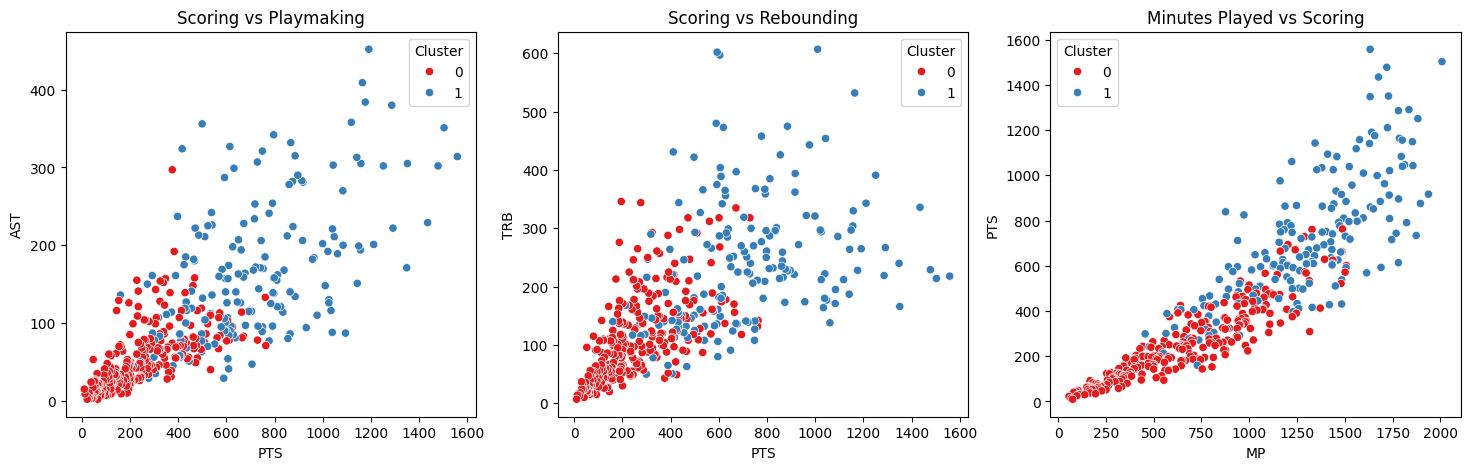

In [43]:

#Review the results compared to my first plots with 4 clusters
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Plot 1
# #Comparing these two features separates the ballers that score often vs the ones that move the ball and create points
sns.scatterplot(
    data=nba_data2,
    x="PTS",
    y="AST",
    hue="Cluster",
    palette="Set1",
    ax=axes[0]
)
axes[0].set_title("Scoring vs Playmaking")



# Plot 2
# Plotting these features separates the big players from the smaller guards, aka paint vs shooters
sns.scatterplot(
    data=nba_data2,
    x="PTS",
    y="TRB",
    hue="Cluster",
    palette="Set1",
    ax=axes[1]
)
axes[1].set_title("Scoring vs Rebounding")


# Plot 3
# Comparing these two features shows the role of the player in the game vs their actual productive contribution
sns.scatterplot(
    data=nba_data2,
    x="MP",
    y="PTS",
    hue="Cluster",
    palette="Set1",
    ax=axes[2]
)
axes[2].set_title("Minutes Played vs Scoring")

plt.tight_layout
plt.show()

In [44]:
#Once again evaluate the quality of the clustering using total variance explained and silhouette scores
# Score per game from before
score_pg = silhouette_score(scaled_features_pg, nba_data2["Cluster_pg"])
print("score_pg", score_pg)

# Total Sum of Squares
overall_mean = np.mean(scaled_features_pg, axis=0)
tss = np.sum((scaled_features_pg - overall_mean)**2)

# Within-cluster sum of squares
wcss = kmeans.inertia_

# Variance explained 
v_explained = 1 - (wcss / tss)

print("V explained:", v_explained)

score_pg 0.3085525090763887
V explained: 0.43043848077328817


##### With k=2, we're splitting the laegue into two main groups, higher-impact and lower-impact players. I feel like k=2 fails to pick up the types of overall players (gaurds, centers, defensive stars, etc.) With that, two clusters capture some structure, but theres still a lot that can't be easily reasoned.

In [45]:
#Converting salary to remove $ and , 
# Regex is calling for the search and replacement of these characters
nba_data2["Salary"] = (nba_data2["Salary"].replace('[\$,]', '', regex=True).astype(float))

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_18913/222236330.py:3: SyntaxWarning: invalid escape sequence '\$'
  nba_data2["Salary"] = (nba_data2["Salary"].replace('[\$,]', '', regex=True).astype(float))


In [46]:
#Use the model to select players for Mr. Rooney to consider
# Determining the average player salary per cluster
nba_data2["Cluster_Avg_Salary"] = nba_data2.groupby("Cluster_pg")["Salary"].transform("mean")

#Comparing player salary to cluster average salary
# If negative, player is cheaper than players of similar skill, opposite if positive
nba_data2["Salary_Difference"] = nba_data2["Salary"] - nba_data2["Cluster_Avg_Salary"]

#To find the 10 best "deals"
nba_data2.sort_values("Salary_Difference").head(20)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB_pg,AST_pg,STL_pg,BLK_pg,TOV_pg,MP_pg,Cluster_pg,Cluster,Cluster_Avg_Salary,Salary_Difference
63,62.0,Russell Westbrook,37.0,SAC,SF,52.0,46.0,1521.0,294.0,683.0,...,5.692308,6.576923,1.307692,0.153846,3.403846,29.250000,2,1,2.782430e+07,-2.552803e+07
88,83.0,Collin Gillespie,26.0,PHO,PG,54.0,35.0,1527.0,250.0,576.0,...,4.166667,4.685185,1.388889,0.222222,1.648148,28.277778,2,1,2.782430e+07,-2.552803e+07
167,148.0,Isaiah Collier,21.0,UTA,PG,48.0,12.0,1225.0,186.0,365.0,...,2.604167,7.416667,1.000000,0.291667,2.500000,25.520833,2,1,2.782430e+07,-2.518610e+07
101,96.0,Kyshawn George,22.0,WAS,SF,43.0,43.0,1296.0,233.0,528.0,...,5.441860,4.813953,1.069767,0.883721,2.767442,30.139535,2,1,2.782430e+07,-2.485754e+07
69,68.0,Jaime Jaquez Jr.,24.0,MIA,SF,51.0,1.0,1473.0,314.0,622.0,...,5.431373,4.725490,0.843137,0.294118,2.254902,28.882353,2,1,2.782430e+07,-2.396270e+07
52,50.0,Ryan Rollins,23.0,MIL,PG,51.0,46.0,1633.0,330.0,712.0,...,4.607843,5.450980,1.470588,0.392157,2.392157,32.019608,2,1,2.782430e+07,-2.382430e+07
19,19.0,Keyonte George,22.0,UTA,PG,48.0,48.0,1629.0,358.0,782.0,...,3.895833,6.520833,1.083333,0.291667,3.291667,33.937500,2,1,2.782430e+07,-2.354534e+07
174,154.0,Kevin Porter Jr.,25.0,MIL,PG,28.0,26.0,943.0,171.0,382.0,...,5.214286,7.607143,2.178571,0.428571,3.214286,33.678571,2,1,2.782430e+07,-2.269030e+07
191,168.0,Jalen Williams,24.0,OKC,SG,26.0,26.0,755.0,175.0,365.0,...,4.653846,5.423077,1.269231,0.346154,1.923077,29.038462,2,1,2.782430e+07,-2.124331e+07
44,42.0,Payton Pritchard,28.0,BOS,PG,53.0,48.0,1732.0,344.0,744.0,...,4.169811,5.339623,0.773585,0.094340,1.188679,32.679245,2,1,2.782430e+07,-2.059216e+07


In [47]:
# Now lets take a look at the top 10 worst "deals" regarding salary
nba_data2.sort_values("Salary_Difference", ascending=False).head(10)

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB_pg,AST_pg,STL_pg,BLK_pg,TOV_pg,MP_pg,Cluster_pg,Cluster,Cluster_Avg_Salary,Salary_Difference
78,75.0,Zach LaVine,30.0,SAC,SG,39.0,37.0,1224.0,262.0,547.0,...,2.769231,2.282051,0.717949,0.256410,1.897436,31.384615,0,1,1.116281e+07,3.633685e+07
219,192.0,Anthony Davis,32.0,DAL,PF,20.0,20.0,626.0,169.0,334.0,...,11.050000,2.800000,1.100000,1.650000,2.050000,31.300000,1,1,1.807183e+07,3.605462e+07
32,33.0,Karl-Anthony Towns,30.0,NYK,C,51.0,51.0,1597.0,333.0,714.0,...,11.901961,2.901961,0.862745,0.607843,2.529412,31.313725,1,1,1.807183e+07,3.507044e+07
23,24.0,Stephen Curry,37.0,GSW,PG,39.0,39.0,1222.0,348.0,744.0,...,3.538462,4.846154,1.128205,0.410256,2.846154,31.333333,2,1,2.782430e+07,3.178251e+07
75,72.0,Evan Mobley,24.0,CLE,PF,42.0,40.0,1402.0,291.0,568.0,...,8.761905,4.047619,0.904762,1.952381,2.095238,33.380952,1,1,1.807183e+07,2.832227e+07
57,56.0,Joel Embiid,31.0,PHI,C,31.0,31.0,972.0,278.0,563.0,...,7.483871,3.903226,0.645161,1.096774,2.967742,31.354839,2,1,2.782430e+07,2.740022e+07
6,8.0,Kevin Durant,37.0,HOU,SF,50.0,50.0,1835.0,452.0,894.0,...,5.340000,4.440000,0.840000,0.880000,3.220000,36.700000,2,1,2.782430e+07,2.688430e+07
55,54.0,Giannis Antetokounmpo,31.0,MIL,PF,30.0,30.0,876.0,314.0,487.0,...,10.033333,5.600000,0.900000,0.733333,3.333333,29.200000,2,1,2.782430e+07,2.630215e+07
74,71.0,Jimmy Butler,36.0,GSW,SF,38.0,38.0,1182.0,240.0,462.0,...,5.552632,4.868421,1.447368,0.210526,1.578947,31.105263,2,1,2.782430e+07,2.630215e+07
121,111.0,Deandre Ayton,27.0,LAL,C,46.0,46.0,1299.0,278.0,412.0,...,8.456522,0.891304,0.630435,0.956522,1.369565,28.239130,1,1,1.807183e+07,2.558299e+07
